## Recipe 3-1: FBProphet Univariate Time Series Modeling

Thuật toán Facebook Prophet hoạt động cực kỳ hiệu quả trên dữ liệu có xu hướng cộng dồn (additive trends) và nhiều tính thời vụ (multiple seasonalities)

In [1]:
import numpy as np
import pandas as pd
from prophet import Prophet
from prophet.plot import plot_plotly, add_changepoints_to_plot
from sklearn.model_selection import train_test_split
import plotly.offline as py
import matplotlib.pyplot as plt
py.init_notebook_mode()
%matplotlib inline

c:\Users\ACER\Documents\VS CODE\KPDL_seminar\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("./data/avocado.csv").drop(columns=["Unnamed: 0"])
df.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


>Bảng dữ liệu ghi lại doanh số bán lẻ bơ theo từng tuần, bao gồm các thông tin chính sau:
- Date: Ngày ghi nhận (ngày kết thúc tuần)
- AveragePrice: Giá bán trung bình của một quả bơ
- Total Volume: Tổng số lượng bơ bán ra trong tuần
- 4046: Bơ cỡ nhỏ / trung đã bán
- 4225: Bơ cỡ lớn đã bán
- 4770: Bơ cỡ rất lớn đã bán
- Total Bags: Tổng số túi bơ đã bán
- Small Bags: Số túi nhỏ đã bán
- Large Bags: Số túi lớn đã bán
- XLarge Bags: Số túi cực lớn đã bán
- type: Loại bơ. Gồm 2 loại: conventional (thông thường) hoặc organic (hữu cơ)
- year: Năm của dữ liệu đó (2015 - 2018)
- region: Khu vực bán hàng (vd: Albany, California...)

In [3]:
val = df.Date.nunique()
print(f"Số lượng ngày là: {val}")

Số lượng ngày là: 169


In [4]:
train_df = pd.DataFrame()
train_df['ds'] = pd.to_datetime(df["Date"])
train_df['y'] = df.iloc[:,1]
train_df.head()

,ds,y
0,2015-12-27,1.33
1,2015-12-20,1.35
2,2015-12-13,0.93
3,2015-12-06,1.08
4,2015-11-29,1.28


>Đoạn code này dùng để chuẩn hóa dữ liệu về đúng định dạng mà Prophet yêu cầu.
- Tạo một bảng dữ liệu mới train_df
- Lấy cột Date từ dữ liệu gốc → đổi thành dạng ngày → đặt tên là ds (cột chứa thông tin thời gian)
- Lấy cột giá bơ (AveragePrice) → đặt tên là y (biến mục tiêu)

In [5]:
# Initializing basic prophet model:
basic_prophet_model = Prophet()
basic_prophet_model.fit(train_df)

15:51:25 - cmdstanpy - INFO - Chain [1] start processing
15:51:33 - cmdstanpy - INFO - Chain [1] done processing


>Dùng để khởi tạo và huấn luyện mô hình Prophet.
- Prophet(): Tạo một mô hình dự báo thời gian
- .fit(train_df): Cho mô hình học từ dữ liệu

In [6]:
# Creating future dataframe for forecast:
future_df = basic_prophet_model.make_future_dataframe(include_history=True,periods=300)
future_df.tail()

,ds
464,2019-01-15
465,2019-01-16
466,2019-01-17
467,2019-01-18
468,2019-01-19


>Dùng để tạo dữ liệu thời gian trong tương lai để mô hình Prophet dự đoán
- make_future_dataframe: Tạo khung thời gian tương lai (Ví dụ: 300 ngày tiếp theo)

In [7]:
future_df.head()

,ds
0,2015-01-04
1,2015-01-11
2,2015-01-18
3,2015-01-25
4,2015-02-01


In [8]:
# Getting the forecast
forecast_df = basic_prophet_model.predict(future_df)

>Dùng mô hình đã học để dự đoán giá trị trong tương lai

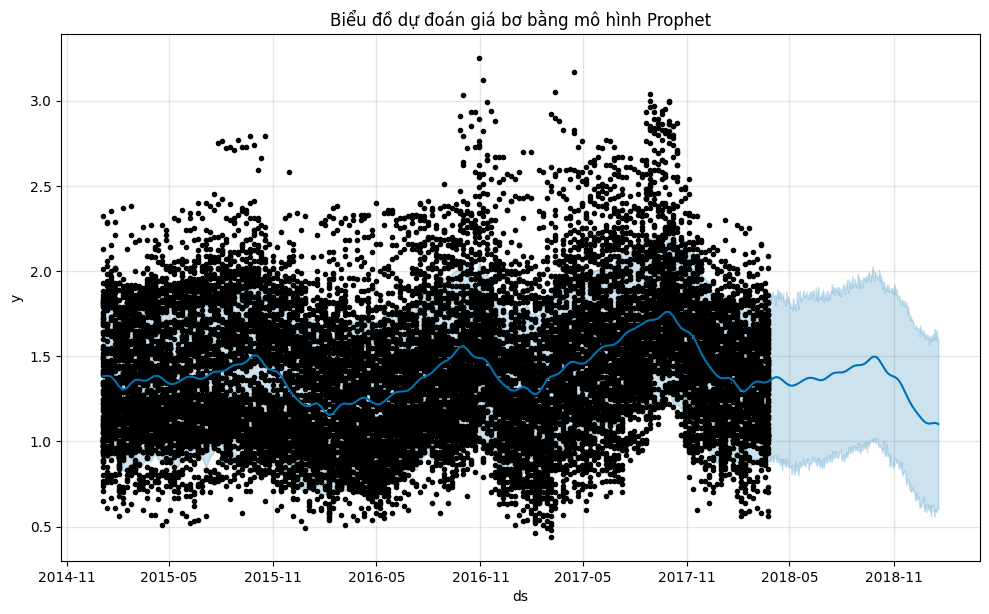

In [9]:
plot1 = basic_prophet_model.plot(forecast_df)
import matplotlib.pyplot as plt
plt.title("Biểu đồ dự đoán giá bơ bằng mô hình Prophet")
plt.show()

- Chấm đen (Actual Data): Dữ liệu thực tế trong quá khứ, dùng để huấn luyện mô hình.
- Đường màu xanh (Forecast): Giá trị dự báo, được tạo từ xu hướng, tính thời vụ và các yếu tố khác.
    + Phần trùng với chấm đen: mô hình tái hiện lại dữ liệu sau khi học
    + Phần bên phải: dự báo cho tương lai (300 ngày)
- Vùng xanh nhạt (Confidence Interval): Khoảng tin cậy, thể hiện độ bất định của dự báo
    + Vùng hẹp → mô hình tự tin
    + Vùng rộng → độ bất định cao

=> Ở phần dự báo tương lai, vùng tin cậy mở rộng do dự báo xa và dữ liệu có nhiều biến động

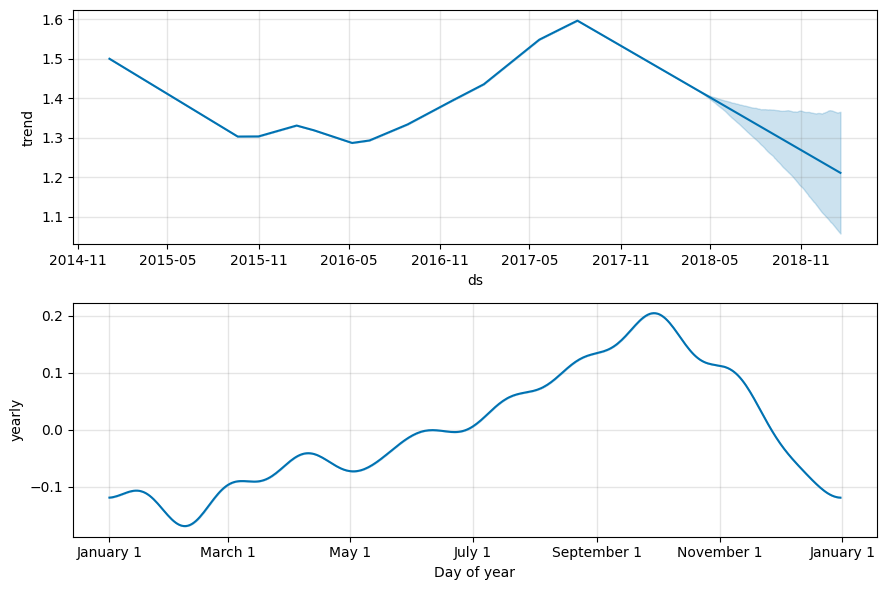

In [10]:
# to view  the forecast components
plot2 = basic_prophet_model.plot_components(forecast_df)

>**Trend (Xu hướng)**: 
- Thể hiện xu hướng dài hạn của giá bơ theo thời gian. Giá có giai đoạn giảm nhẹ, sau đó tăng mạnh và đạt đỉnh khoảng năm 2017, rồi giảm dần về cuối giai đoạn.
- Mô hình tự động phát hiện các điểm thay đổi xu hướng (change points) – nơi xu hướng tăng/giảm đột ngột.
- Tham số changepoint_prior_scale điều chỉnh độ linh hoạt của đường xu hướng:
    + Giá trị cao → đường uốn cong nhiều, dễ bị quá khớp
    + Giá trị thấp → đường mượt hơn, ít nhạy với biến động

>**Yearly (Tính thời vụ theo năm)**: 
- Thể hiện quy luật lặp lại hàng năm của giá bơ từ tháng 1 đến tháng 12.
- Giá có xu hướng:
    + Tăng dần và đạt đỉnh vào khoảng tháng 9–10
    + Giảm vào đầu năm

=> Mô hình cho thấy giá bơ chịu ảnh hưởng bởi cả xu hướng dài hạn và chu kỳ lặp lại theo năm, trong đó giai đoạn cuối năm thường có giá cao hơn.

## Recipe 3-2: FBProphet Modeling by Controlling the Change Points

Trong thực tế, xu hướng của giá bơ không phải lúc nào cũng đi theo một đường thẳng cố định. Sẽ có những thời điểm thị trường biến động đột ngột (ví dụ: do chính sách mới hoặc thiên tai). Prophet gọi những thời điểm đó là Change Points

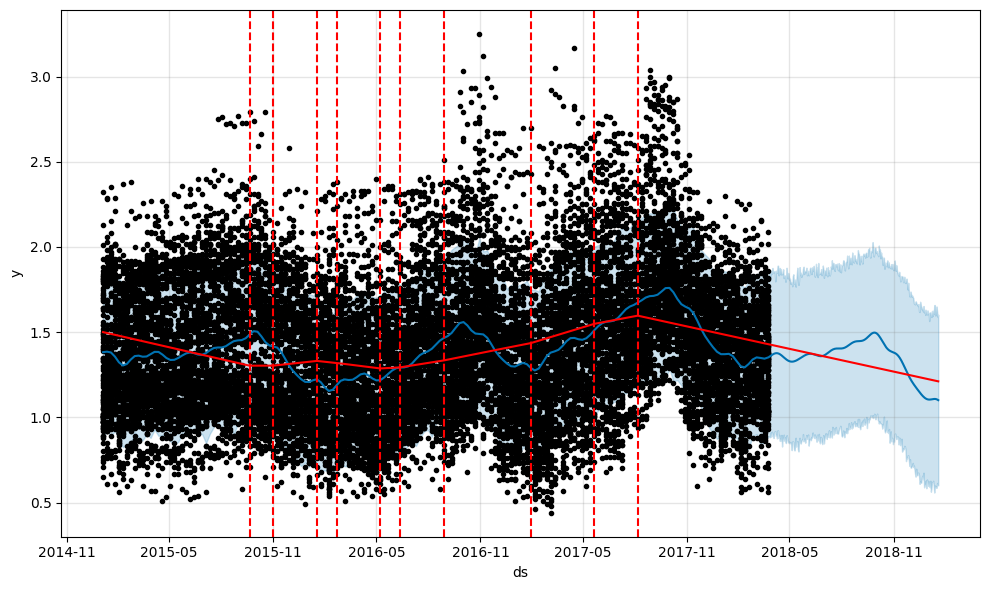

In [11]:
# Prophet detects changepoints by first specifying a large number of potential changepoints at which the rate is allowed to change
# Plotting the changepoints
plot3 = basic_prophet_model.plot(forecast_df)
adding_changepoints = add_changepoints_to_plot(plot3.gca(), basic_prophet_model, forecast_df)

- Mô đình mặc định chọn ra 25 điểm thay đổi trong 80% trong thời gian đầu của dữ liệu. 
- Sau đó xác định nơi nào xu hướng: tăng → giảm hoặc giảm → tăng => Những điểm này gọi là changepoints
- Đường gạch đỏ là sự thay đổi đột ngột về xu hướng trong số những changepoint

In [12]:
# printing the change points:
basic_prophet_model.changepoints

584     2015-02-08
1168    2015-03-15
1752    2015-04-26
2336    2015-05-31
2920    2015-07-12
3504    2015-08-16
4087    2015-09-20
4671    2015-11-01
5255    2015-12-06
5839    2016-01-17
6423    2016-02-21
7007    2016-03-27
7591    2016-05-08
8175    2016-06-12
8759    2016-07-24
9343    2016-08-28
9927    2016-10-02
10511   2016-11-13
11094   2016-12-18
11678   2017-01-29
12262   2017-03-05
12846   2017-04-09
13430   2017-05-21
14014   2017-06-25
14598   2017-08-06
Name: ds, dtype: datetime64[ns]

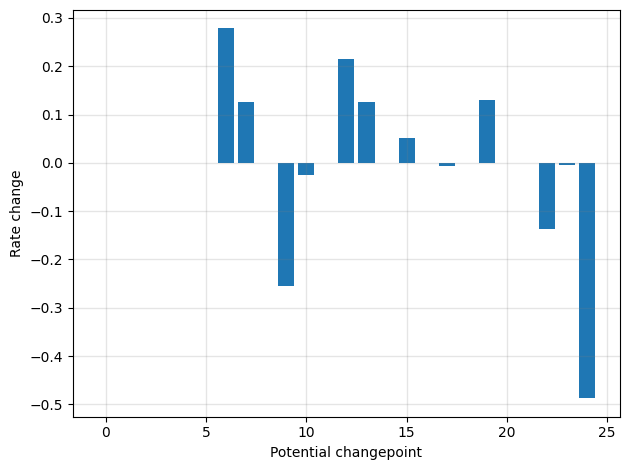

In [13]:
# checking the magnitude of the change points:
deltas = basic_prophet_model.params['delta'].mean(0)
plot4 = plt.figure(facecolor='w')
ax = plot4.add_subplot(111)
ax.bar(range(len(deltas)), deltas)
ax.grid(True, which='major', c='gray', ls='-', lw=1, alpha=0.2)
ax.set_ylabel('Rate change')
ax.set_xlabel('Potential changepoint')
plot4.tight_layout()

Mức độ quan trọng của changepoint lên xu hướng (Độ dốc). mức độ thay đổi tốc độ tăng trưởng (rate change) tại thời điểm đó
- Trục x: thứ tự changepoint
- Trục y: Giá trị thay đổi của tốc độ tăng trưởng
- Cường độ (Magnitude) chính là độ gắt của cú bẻ lái tại khúc cua đó
- Nếu cường độ bằng 0: Người lái xe vẫn đi thẳng, không có gì thay đổi.
- Nếu cường độ lớn: Người lái xe bẻ lái rất gấp (có thể là ngoặt lên hoặc rẽ xuống)

15:51:41 - cmdstanpy - INFO - Chain [1] start processing
15:51:49 - cmdstanpy - INFO - Chain [1] done processing


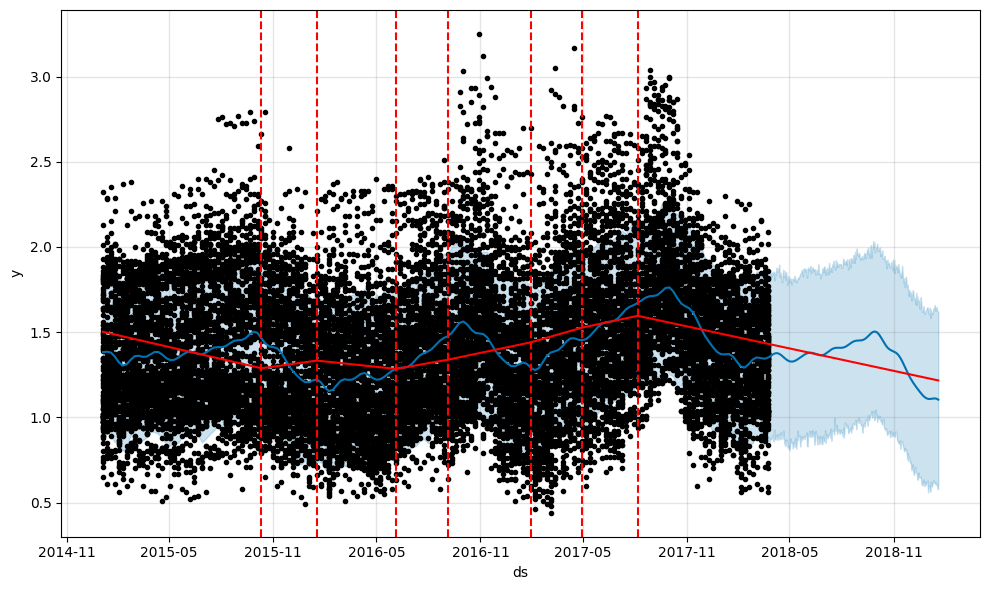

In [14]:
# setting the n_changepoints as hyperparameter:
prophet_model_changepoint= Prophet(n_changepoints=20, yearly_seasonality=True)
# getting the forecast
forecast_df_changepoint = prophet_model_changepoint.fit(train_df).predict(future_df)
# plotting the forecast with change points
plot5 = prophet_model_changepoint.plot(forecast_df_changepoint)
adding_changepoints = add_changepoints_to_plot(plot5.gca(), prophet_model_changepoint, forecast_df_changepoint)

- Mô hình được thiết lập với 20 changepoints → giúp giảm độ phức tạp so với mặc định
- Việc giảm số điểm này giúp mô hình bỏ qua các biến động nhỏ (noise) và chỉ tập trung vào những thay đổi quan trọng của xu hướng
- Kết quả:
    + Đường dự báo trở nên mượt và ổn định hơn
    + Vùng màu xanh (khoảng bất định) thu hẹp lại → mô hình tự tin hơn
- Ý nghĩa:
    + Tránh việc mô hình phản ứng quá mức với biến động nhỏ (giảm overfitting)
    + 20 là con số cân bằng giữa Overfitting và Underfitting, vẫn giữ được khả năng nắm bắt xu hướng chính

In [15]:
# printing the change points:
prophet_model_changepoint.changepoints

730     2015-02-15
1460    2015-04-05
2190    2015-05-24
2920    2015-07-12
3650    2015-08-23
4379    2015-10-11
5109    2015-11-29
5839    2016-01-17
6569    2016-02-28
7299    2016-04-17
8029    2016-06-05
8759    2016-07-24
9489    2016-09-04
10219   2016-10-23
10948   2016-12-11
11678   2017-01-29
12408   2017-03-12
13138   2017-04-30
13868   2017-06-18
14598   2017-08-06
Name: ds, dtype: datetime64[ns]

15:51:53 - cmdstanpy - INFO - Chain [1] start processing
15:51:59 - cmdstanpy - INFO - Chain [1] done processing


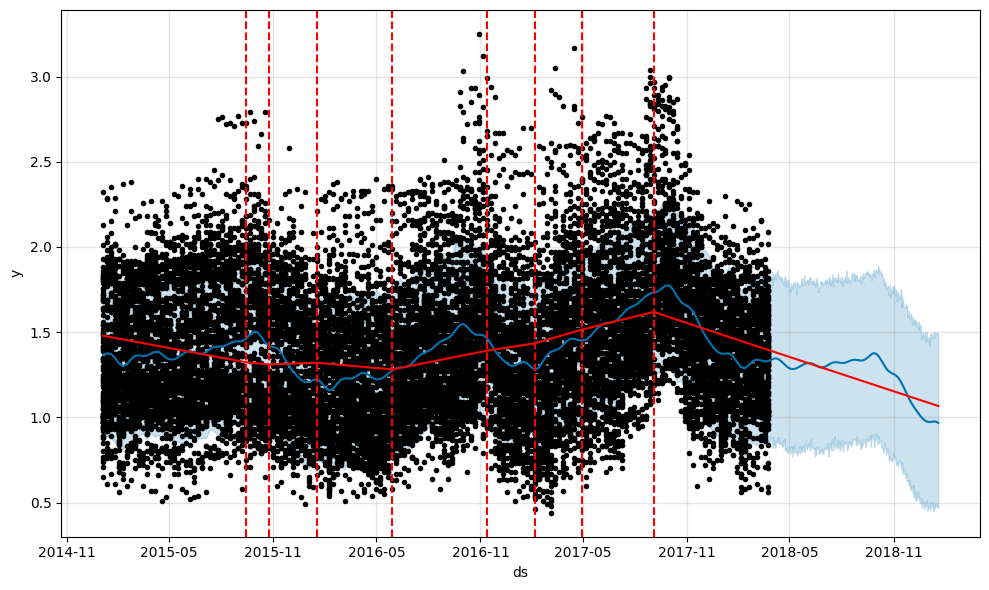

In [16]:
# setting the changepoint_range as hyperparameter:
prophet_model_changepoint2 = Prophet(changepoint_range=0.9, yearly_seasonality=True)
# getting the forecast
forecast_df_changepoint2 = prophet_model_changepoint2.fit(train_df).predict(future_df)
# plotting the forecast with change points
plot6 = prophet_model_changepoint2.plot(forecast_df_changepoint2)
adding_changepoints = add_changepoints_to_plot(plot6.gca(), prophet_model_changepoint2, forecast_df_changepoint2)

- Ở Plot 6, mô hình được thiết lập với changepoint_range = 0.9, tức là cho phép xác định các điểm thay đổi xu hướng trong 90% dữ liệu đầu.
- Vì vậy, các changepoints (vạch đỏ) xuất hiện gần hơn với vùng dự báo tương lai, giúp mô hình nhạy hơn với những biến động mới nhất của dữ liệu.
- Kết quả:
    + Đường dự báo có xu hướng bám sát các biến động gần cuối hơn
    + Vùng bất định (màu xanh nhạt) có thể thu hẹp lại do mô hình “tự tin” hơn
- Tuy nhiên: Nếu các biến động gần cuối chỉ là nhiễu → mô hình dễ bị quá khớp (overfitting) và dự báo có thể kém chính xác

In [17]:
prophet_model_changepoint2.changepoints.count()

25

## Recipe 3-3: FBProphet Modeling by Adjusting Trends

15:52:03 - cmdstanpy - INFO - Chain [1] start processing
15:52:09 - cmdstanpy - INFO - Chain [1] done processing


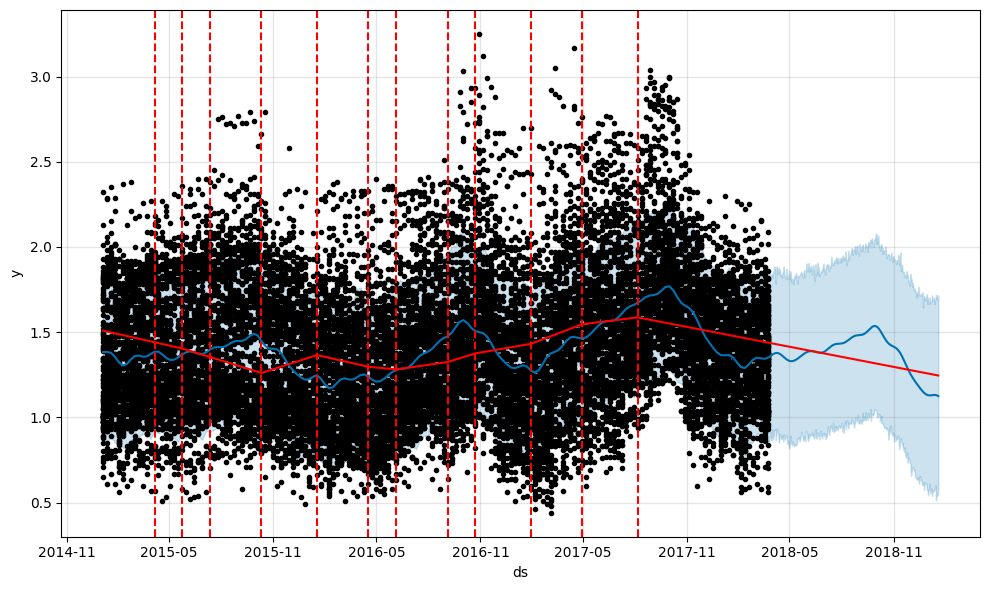

In [18]:
# setting the changepoint_prior_scale as hyperparameter:
prophet_model_trend = Prophet(n_changepoints=20, yearly_seasonality=True, changepoint_prior_scale=0.08)
# getting the forecast
forecast_df_trend = prophet_model_trend.fit(train_df).predict(future_df)
# plotting the forecast with change points
plot7 = prophet_model_trend.plot(forecast_df_trend)
adding_changepoints = add_changepoints_to_plot(plot7.gca(), prophet_model_trend, forecast_df_trend)

- Tạo mô hình Prophet với:
    + n_changepoints = 20 → giới hạn số điểm thay đổi xu hướng
    + changepoint_prior_scale = 0.08 → tăng độ linh hoạt của xu hướng giúp mô hình bớt nhạy với nhiễu và tạo xu hướng ổn định hơn
- Huấn luyện mô hình và dự đoán dữ liệu
- Vẽ biểu đồ kèm các changepoints

15:52:13 - cmdstanpy - INFO - Chain [1] start processing
15:52:14 - cmdstanpy - INFO - Chain [1] done processing


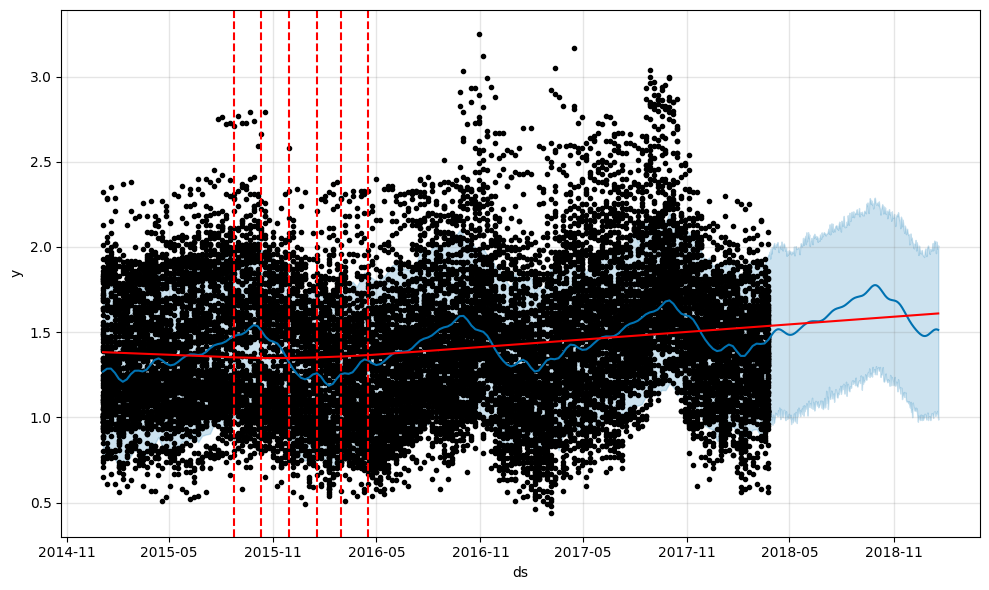

In [19]:
# setting the changepoint_prior_scale as hyperparameter:
prophet_model_trend2 = Prophet(n_changepoints=20, yearly_seasonality=True, changepoint_prior_scale=0.001)
# getting the forecast
forecast_df_trend2 = prophet_model_trend2.fit(train_df).predict(future_df)
# plotting the forecast with change points
plot8 = prophet_model_trend2.plot(forecast_df_trend2)
adding_changepoints = add_changepoints_to_plot(plot8.gca(), prophet_model_trend2, forecast_df_trend2)

- Tạo mô hình Prophet với:
    + n_changepoints = 20
    + changepoint_prior_scale = 0.001 (rất nhỏ)
- Ý nghĩa chính:
    + Giá trị rất nhỏ → đường xu hướng rất cứng, ít thay đổi
    + Mô hình gần như bỏ qua các changepoints
- Tác động:
    + Mô hình ít nhạy với biến động dữ liệu
    + Chỉ giữ lại xu hướng dài hạn
    + Giảm mạnh noise và overfitting
    + Nhưng dễ bị underfitting (bỏ qua biến động quan trọng)
- Kết quả trên biểu đồ:
    + Đường dự báo rất mượt, gần như đường thẳng
    + Ít hoặc không có điểm gãy
    + Vùng bất định ổn định nhưng có thể không phản ánh đúng thực tế

=> Giá trị changepoint_prior_scale quá nhỏ giúp mô hình rất ổn định nhưng dễ mất thông tin quan trọng của dữ liệu.

## Recipe 3-4: FBProphet Modeling with Holidays

- Phản ánh những biến động ngắn hạn, đột ngột tại các mốc thời gian cụ thể chịu ảnh hưởng mạnh mẽ bởi các sự kiện đặc biệt như ngày lễ hoặc kỳ nghỉ
- Mục đích: Giúp mô hình không hiểu nhầm các biến động đột ngột trong ngày lễ là một phần của quy luật thông thường, từ đó cải thiện độ chính xác dự báo

In [20]:
# creating a custom holidays dataframe
holidays_df = pd.DataFrame({
  'holiday': 'avocado season',
  'ds': pd.to_datetime(['2014-07-31', '2014-09-16', 
                        '2015-07-31', '2015-09-16',
                        '2016-07-31', '2016-09-16',
                        '2017-07-31', '2017-09-16',
                       '2018-07-31', '2018-09-16',
                        '2019-07-31', '2019-09-16']),
  'lower_window': -1,
  'upper_window': 0,
})

>Đoạn code này tạo một bảng dữ liệu các sự kiện đặc biệt (holidays) để đưa vào mô hình Prophet.

- holiday: 'avocado season': Tên của sự kiện (Tết, lễ, mùa cao điểm,…)
- ds: pd.to_datetime([...]): Danh sách các ngày diễn ra sự kiện qua từng năm
    + Hàm pd.to_datetime chuyển dữ liệu sang định dạng ngày để mô hình hiểu được
- lower_window = -1: Xác định phạm vi ảnh hưởng trước ngày sự kiện
    + Giá trị -1 → ảnh hưởng bắt đầu từ 1 ngày trước đó
- upper_window = 0: Xác định phạm vi ảnh hưởng sau ngày sự kiện
    + Giá trị 0 → ảnh hưởng chỉ trong ngày chính, không kéo dài thêm

=> Đoạn code này giúp mô hình hiểu rằng vào các thời điểm “mùa bơ”, giá có thể bị ảnh hưởng, kể cả 1 ngày trước sự kiện.

15:52:18 - cmdstanpy - INFO - Chain [1] start processing
15:52:25 - cmdstanpy - INFO - Chain [1] done processing


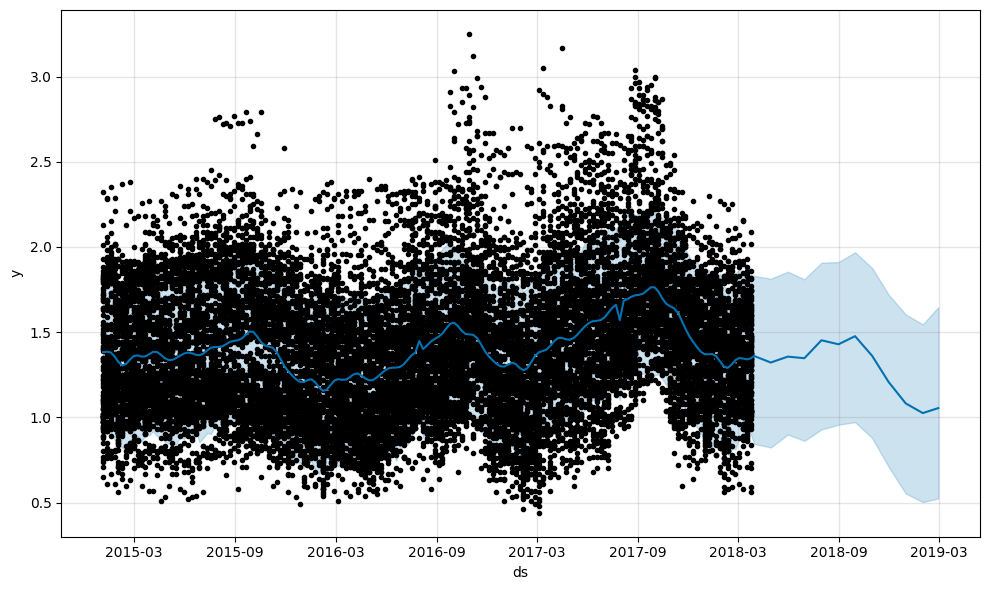

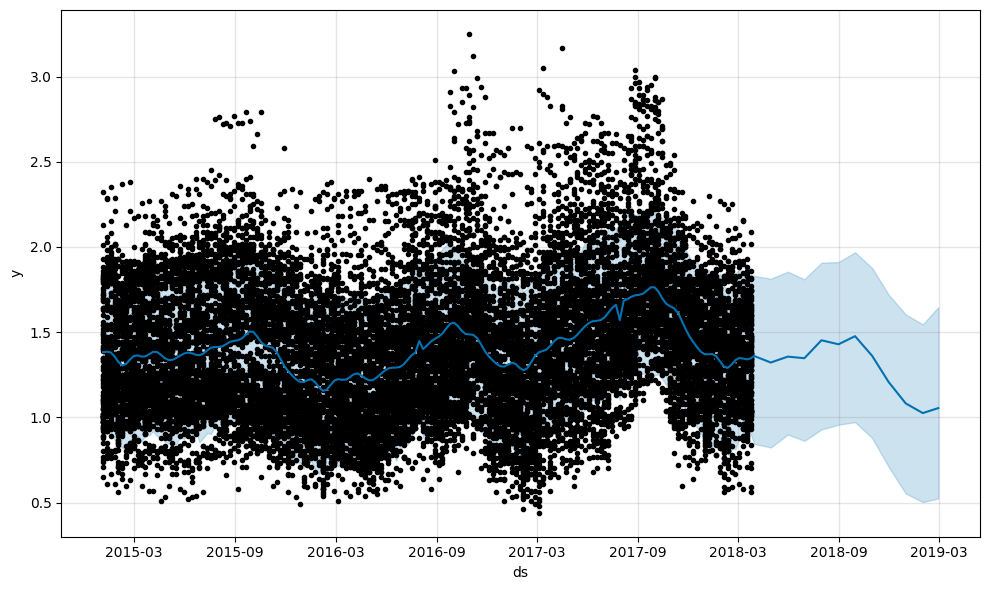

In [21]:
# Initializing prophet model with holidays dataframe:
prophet_model_holiday = Prophet(holidays=holidays_df)
prophet_model_holiday.fit(train_df)
# Creating future dataframe for forecast:
future_df = prophet_model_holiday.make_future_dataframe(periods=12, freq = 'm')
# Getting the forecast
forecast_df = prophet_model_holiday.predict(future_df)
prophet_model_holiday.plot(forecast_df)

- Đường dự báo bám theo xu hướng chung của dữ liệu
- Có dao động theo mùa và chịu ảnh hưởng của holiday
- Ở phần bên phải (tương lai): Dự báo 12 tháng tiếp theo, xu hướng có biến động nhẹ rồi giảm dần
- Vùng bất định:
    + Mở rộng dần về tương lai → độ chắc chắn giảm
    + Có thể thay đổi quanh các thời điểm “mùa bơ”

=> Mô hình sử dụng thêm yếu tố mùa bơ để dự đoán, giúp phản ánh tốt hơn các biến động giá theo sự kiện và xu hướng trong tương lai

## Recipe 3-5: FBProphet Modeling with Added Regressors

In [22]:
# Label encoding type column
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df.iloc[:,10] = le.fit_transform(df.iloc[:,10])
df.head(2)

C:\Users\ACER\AppData\Local\Temp\ipykernel_21492\2211661385.py:4: DeprecationWarning:

In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`



,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,0,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,0,2015,Albany


- Dùng LabelEncoder để mã hóa cột type
- Chuyển dữ liệu từ chữ → số: conventional → 0, organic → 1

=> Giúp mô hình xử lý được dữ liệu phân loại

In [23]:
data = df[['Date', 'Total Volume', '4046', '4225', '4770', 'Small Bags', 'type']]
data.rename(columns={'Date':'ds'},inplace=True)
data['y'] = df.iloc[:,1]

C:\Users\ACER\AppData\Local\Temp\ipykernel_21492\4052009751.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\ACER\AppData\Local\Temp\ipykernel_21492\4052009751.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



- Tạo DataFrame mới data gồm các cột: Date, Total Volume, 4046, 4225, 4770, Small Bags, type
- Đổi tên cột: Date → ds
- Tạo cột y: Lấy từ cột thứ 2 của df (AveragePrice)

=> Chuẩn bị dữ liệu gồm biến thời gian (ds), giá trị dự đoán (y) và các đặc trưng liên quan để đưa vào mô hình

In [24]:
# train-test split
train_df = data[:18000]
test_df = data[18000:]

Chia dữ liệu thành 2 phần:
- train_df = data[:18000] → dữ liệu huấn luyện → Train model trên train_df
- test_df = data[18000:] → dữ liệu kiểm tra → Đánh giá độ chính xác trên test_df

In [25]:
#Initializing Prophet model and adding additional Regressor
prophet_model_regressor = Prophet()
prophet_model_regressor.add_regressor('type')
prophet_model_regressor.add_regressor('Total Volume')
prophet_model_regressor.add_regressor('4046')
prophet_model_regressor.add_regressor('4225')
prophet_model_regressor.add_regressor('4770')
prophet_model_regressor.add_regressor('Small Bags')

- Khởi tạo mô hình Prophet sau đó thêm các biến bổ sung (regressors) vào mô hình vì không chỉ dựa vào thời gian (ds) mà còn dùng thêm các yếu tố khác ảnh hưởng đến giá

In [26]:
# Fitting the data
prophet_model_regressor.fit(train_df)
future_df = prophet_model_regressor.make_future_dataframe(periods=249)

15:52:30 - cmdstanpy - INFO - Chain [1] start processing
15:52:47 - cmdstanpy - INFO - Chain [1] done processing


- fit(train_df): Huấn luyện mô hình với dữ liệu train (có cả regressors)
- make_future_dataframe(periods=249): Tạo dữ liệu thời gian trong tương lai (Thêm 249 mốc thời gian để dự đoán)

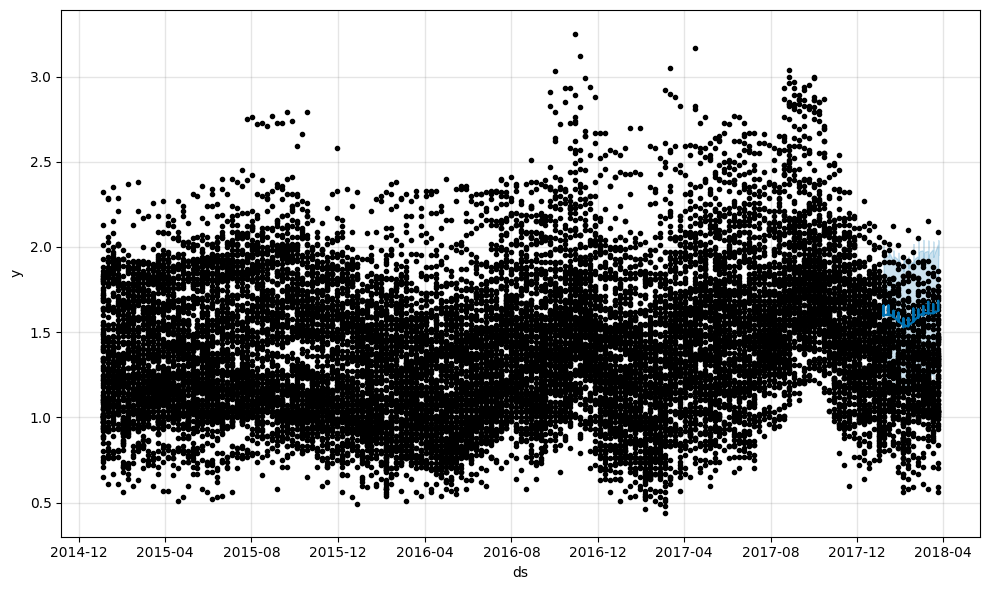

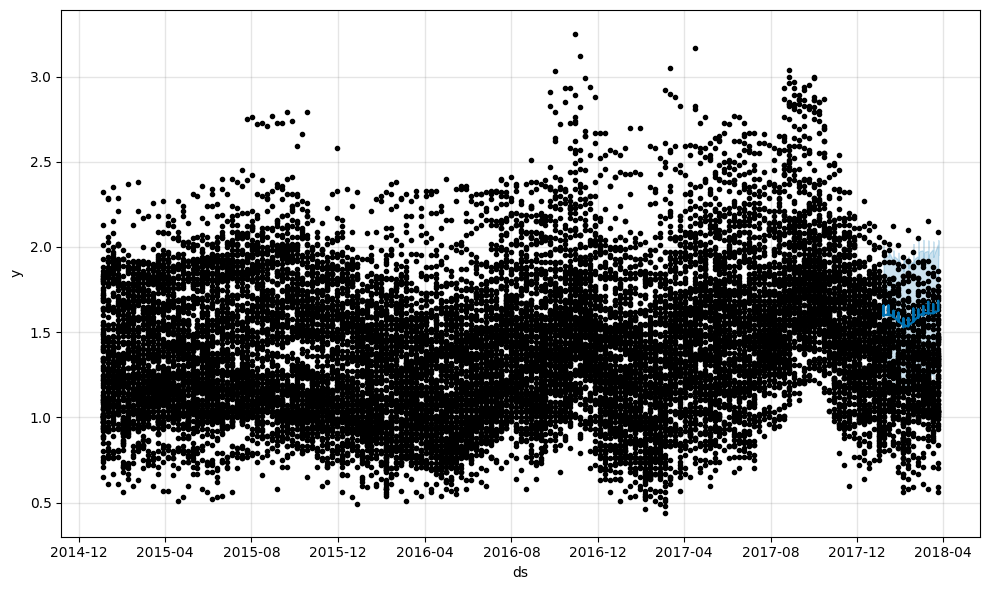

In [27]:
# forecast the data on test
forecast_df = prophet_model_regressor.predict(test_df)
prophet_model_regressor.plot(forecast_df)

- Dự đoán trên tập test (dữ liệu chưa thấy)
- Vẽ biểu đồ so sánh: dữ liệu thật và giá trị dự đoán
    + Chấm đen: dữ liệu thực tế (giá bơ trong tập test)
    + Đường xanh: giá trị dự đoán của mô hình
    + Vùng xanh nhạt: khoảng tin cậy (độ bất định của dự báo)

- Dữ liệu thực tế phân tán khá rộng → giá biến động mạnh
- Đường dự báo tương đối mượt và ổn định
- Ở đoạn cuối (bên phải):
    + Mô hình bắt đầu dự đoán tương lai
    + Có xu hướng dao động nhẹ quanh mức trung bình
- Vùng bất định:
    + Khá hẹp → mô hình tương đối tự tin
    + Nhưng vẫn có sai lệch so với dữ liệu thực tế do dữ liệu nhiễu

## Recipe 3-6: Time Series Forecasting Using Auto-ARIMA

In [28]:
#import all the required libraries
import pandas as pd
from pmdarima.arima import auto_arima
from pmdarima.arima import ADFTest
from matplotlib import pyplot as plt
from sklearn.metrics import r2_score

In [29]:
#read data
auto_arima_data = pd.read_csv('./data/champagne.csv')
auto_arima_data.head()

,Month,Sales
0,1964-01,2815
1,1964-02,2672
2,1964-03,2755
3,1964-04,2721
4,1964-05,2946


Đây là dữ liệu chuỗi thời gian thể hiện doanh số champagne theo từng tháng để phân tích và dự báo xu hướng bán hàng

In [30]:
#check missing values
auto_arima_data.isnull().sum()

Month    0
Sales    0
dtype: int64

In [31]:
#check datatype
auto_arima_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Month   105 non-null    object
 1   Sales   105 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 1.8+ KB


In [32]:
#convert object to datatime and set index
auto_arima_data['Month'] = pd.to_datetime(auto_arima_data['Month'])
auto_arima_data.set_index('Month',inplace=True)
auto_arima_data.head()

,Sales
Month,
1964-01-01,2815
1964-02-01,2672
1964-03-01,2755
1964-04-01,2721
1964-05-01,2946


<Axes: xlabel='Month'>

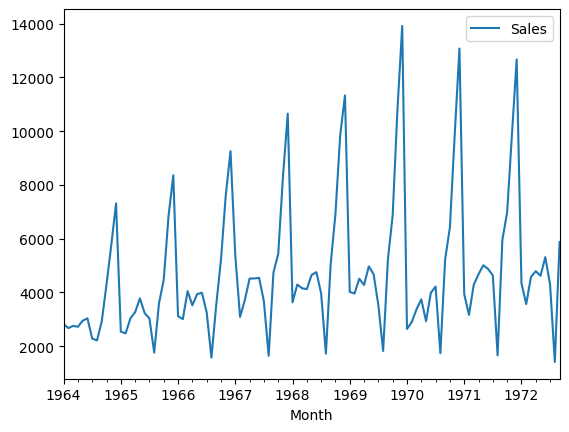

In [33]:
#line plot to understand the pattern
auto_arima_data.plot()

- Doanh số nhìn chung có xu hướng tăng dần theo thời gian
- Mỗi năm đều có đỉnh cao lặp lại (thường cuối năm) (Do nhu cầu tăng vào các dịp lễ, Tết)
- Doanh số có lúc tăng vọt lên rất cao rồi giảm nhanh
- Biên độ dao động ngày càng lớn theo thời gian

=> Biểu đồ cho thấy doanh số champagne tăng theo thời gian và có tính mùa vụ rõ rệt, với các đỉnh lặp lại hàng năm và mức biến động ngày càng lớn

In [34]:
#Stationarity check
stationary_test = ADFTest(alpha= 0.05)
stationary_test.should_diff(auto_arima_data)

(0.01, False)

- Dùng ADFTest để kiểm tra dữ liệu có dừng (stationary) hay không
- alpha = 0.05 → mức ý nghĩa thống kê
- should_diff(...): Trả về kết quả có cần lấy sai phân (differencing) hay không

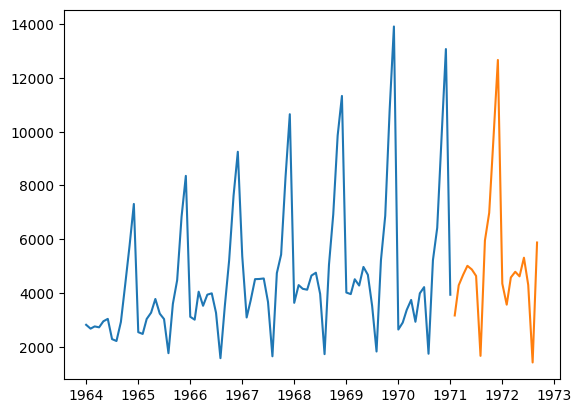

In [35]:
#train test split and plot
train_data = auto_arima_data[:85]
test_data = auto_arima_data[-20:]
plt.plot(train_data)
plt.plot(test_data)

``train_data → dữ liệu train, test_data → dữ liệu test``
- Đường xanh (train): Dữ liệu quá khứ, có xu hướng tăng dần theo thời gian, xuất hiện mùa vụ rõ rệt (đỉnh lặp lại mỗi năm)
- Đường cam (test): Dữ liệu dùng để kiểm tra, nối tiếp hợp lý sau tập train, vẫn giữ xu hướng và mùa vụ tương tự

In [36]:
#model building with parameters
auto_arima_model = auto_arima(train_data, start_p = 0, d=1,
start_q = 0, max_p = 5, max_d = 5,max_q= 5, start_P = 0, D=1,
start_Q = 0, max_P = 5, max_D = 5,
max_Q= 5, m=12, seasonal = True,
error_action = 'warn', trace = True, supress_warnings= True,
stepwise = True, random_state =20,
n_fits = 50)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1203.853, Time=0.11 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1192.025, Time=0.23 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1176.246, Time=0.54 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=1174.731, Time=0.18 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1176.034, Time=0.46 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=1176.700, Time=0.91 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1175.054, Time=0.23 sec
 ARIMA(0,1,2)(0,1,0)[12]             : AIC=1174.769, Time=0.20 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1194.721, Time=0.06 sec
 ARIMA(1,1,2)(0,1,0)[12]             : AIC=1174.564, Time=0.57 sec
 ARIMA(1,1,2)(1,1,0)[12]             : AIC=inf, Time=1.15 sec
 ARIMA(1,1,2)(0,1,1)[12]             : AIC=inf, Time=1.29 sec
 ARIMA(1,1,2)(1,1,1)[12]             : AIC=1176.945, Time=2.50 sec
 ARIMA(2,1,2)(0,1,0)[12]             : AIC=1176.127, Time=0.57 sec
 ARIMA(1,1,3)(0,1,0)[12]     

Dùng `auto_arima()` để tự động tìm mô hình ARIMA tốt nhất cho dữ liệu train

In [37]:
#model summary
auto_arima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                   85
Model:             SARIMAX(1, 1, 2)x(0, 1, [], 12)   Log Likelihood                -583.282
Date:                             Tue, 07 Apr 2026   AIC                           1174.564
Time:                                     15:53:08   BIC                           1183.670
Sample:                                 01-01-1964   HQIC                          1178.189
                                      - 01-01-1971                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8412      0.152     -5.543      0.000      -1.139      -0.544
ma.L1          0.0513      0.167      0.308      0.758      -0.275       0.378
ma.L2         -0.8673      0.086    -10.134      0.000      -1.035      -0.700
sigma2      5.862e+05   7.03e+04      8.342      0.000    4.48e+05    7.24e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                 8.55
Prob(Q):                              0.83   Prob(JB):                         0.01
Heteroskedasticity (H):               2.61   Skew:                            -0.10
Prob(H) (two-sided):                  0.02   Kurtosis:                         4.68
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

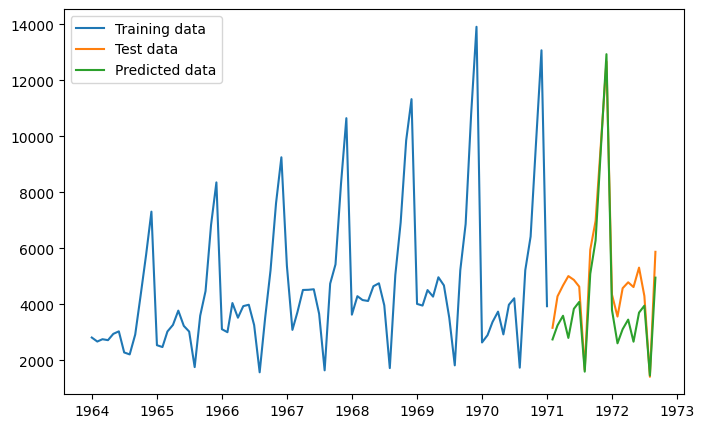

In [38]:
#forecasting on test set
pred = pd.DataFrame(auto_arima_model.predict(n_periods = 20),
index = test_data.index)
pred.columns= ['pred_sales']
#plot
plt.figure(figsize=(8,5))
plt.plot(train_data, label = "Training data")
plt.plot(test_data, label = "Test data")
plt.plot(pred, label = "Predicted data")
plt.legend()
plt.show()

- Đường màu xanh dương (Training data) → Trải dài từ khoảng năm 1964 → 1971 → Có xu hướng tăng dần theo thời gian và có tính chu kỳ (lên xuống theo mùa)
- Đường màu cam (Test data) → Là dữ liệu thực tế nhưng model chưa được thấy khi train → Nằm ở đoạn cuối (khoảng 1971 → 1973) → Dùng để kiểm tra xem model dự đoán có đúng không
- Đường màu xanh lá (Predicted data) → Là dữ liệu do auto_arima_model.predict() dự đoán → Có cùng trục thời gian với test data → Mục tiêu là càng gần đường cam càng tốt

In [39]:
#Evaluating using r square score
test_data['prediction'] = pred
r2_score(test_data['Sales'],test_data['prediction'])

C:\Users\ACER\AppData\Local\Temp\ipykernel_21492\3914927372.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



0.811474135677066

>Dùng để đánh giá độ chính xác của model bằng R² (r-square)

## Recipe 3-7: Multivariate Time Series Forecasting Using the VAR Model

In [40]:
#import all the required libraries
import pandas as pd
from math import sqrt
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.vector_ar.var_model import VAR

In [41]:
#read data
var_data = pd.read_excel('./data/AirQualityUCI.xlsx', parse_dates=[['Date', 'Time']])
var_data.head()

,Date_Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10 18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10 19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10 20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10 21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10 22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


Đây là dataset theo thời gian (time series) về môi trường, dùng để phân tích và dự đoán chất lượng không khí, phát hiện ô nhiễm. Thường gồm: Nồng độ các khí: CO, NO₂, O₃,... Nhiệt độ, độ ẩm, Thời gian đo

In [42]:
var_data['Date_Time'] = pd.to_datetime(var_data.Date_Time ,
format = '%d/%m/%Y %H.%M.%S')
var_data1 = var_data.drop(['Date_Time'], axis=1)
var_data1.index = var_data.Date_Time
var_data1.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Date_Time,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
2004-03-10 19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2004-03-10 20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
2004-03-10 21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
2004-03-10 22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


In [43]:
#missing value treatment
cols = var_data1.columns
for j in cols:
    for i in range(0,len(var_data1)):
        if var_data1[j][i] == -200:
            var_data1[j][i] = var_data1[j][i-1]

C:\Users\ACER\AppData\Local\Temp\ipykernel_21492\3220411477.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Đoạn này dùng để xử lý giá trị bị thiếu (missing value) trong dữ liệu. Thay các giá trị bị thiếu (-200) bằng giá trị ngay trước đó để làm sạch dữ liệu.

In [44]:
#checking stationarity
from statsmodels.tsa.vector_ar.vecm import coint_johansen
#since the test works for only 12 variables, I have randomly dropped
#in the next iteration, I would drop another and check the eigenvalues
test = var_data1.drop([ 'CO(GT)'], axis=1)
coint_johansen(test,-1,1).eig

array([1.75628733e-01, 1.52399674e-01, 1.15090998e-01, 1.04309966e-01,
       9.29562919e-02, 6.90255307e-02, 5.76654697e-02, 3.43596700e-02,
       3.06350634e-02, 1.18801270e-02, 2.46819409e-03, 7.09473977e-05])

Kiểm tra tính dừng và mối quan hệ đồng liên kết giữa các biến bằng Johansen test (dựa trên eigenvalues).
- Bỏ bớt 1 cột để chạy test
- coint_johansen(...).eig → lấy eigenvalues để đánh giá quan hệ giữa các biến

In [45]:
#creating the train and validation set
train_data = var_data1[:int(0.8*(len(var_data1)))]
valid_data = var_data1[int(0.8*(len(var_data1))):]

In [46]:
##fit the model
from statsmodels.tsa.vector_ar.var_model import VAR
var_model = VAR(endog=train_data)
var_model_fit = var_model.fit()
# make prediction on validation
pred = var_model_fit.forecast(var_model_fit.endog,
steps=len(valid_data))
pred

c:\Users\ACER\Documents\VS CODE\KPDL_seminar\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency H will be used.



array([[8.88161065e-01, 8.41803964e+02, 2.71644320e+02, ...,
        1.05743863e+01, 3.48713152e+01, 4.37277520e-01],
       [9.92424381e-01, 8.66262441e+02, 2.69327633e+02, ...,
        9.85432359e+00, 3.74025472e+01, 4.42645045e-01],
       [1.10490663e+00, 8.90900736e+02, 2.67743663e+02, ...,
        9.24271941e+00, 3.96241504e+01, 4.47398014e-01],
       ...,
       [2.13383727e+00, 1.10685527e+03, 2.69411125e+02, ...,
        2.01829088e+01, 4.88992477e+01, 1.11131218e+00],
       [2.13383726e+00, 1.10685527e+03, 2.69411126e+02, ...,
        2.01829090e+01, 4.88992475e+01, 1.11131220e+00],
       [2.13383724e+00, 1.10685527e+03, 2.69411126e+02, ...,
        2.01829093e+01, 4.88992474e+01, 1.11131221e+00]])

- Huấn luyện mô hình VAR và dùng nó để dự đoán dữ liệu validation.


In [47]:
##converting predictions to dataframe
pred1 = pd.DataFrame(index=range(0,len(pred)),columns=cols)
for j in range(0,13):
    for i in range(0, len(pred1)):
        pred1.iloc[i, j] = pred[i, j]
pred1

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,0.888161,841.803964,271.64432,1.982632,595.965721,137.03066,1119.615156,87.815339,829.84466,546.026663,10.574386,34.871315,0.437278
1,0.992424,866.262441,269.327633,2.332532,619.914837,158.117747,1098.381882,90.537193,856.405973,598.407982,9.854324,37.402547,0.442645
2,1.104907,890.900736,267.743663,2.832077,645.634216,177.729196,1078.45843,93.115608,885.665916,648.974793,9.242719,39.62415,0.447398
3,1.219987,914.919521,266.664032,3.407752,671.662218,195.906115,1059.928335,95.57167,915.647307,697.359008,8.722839,41.579793,0.45174
4,1.333743,937.819088,265.921087,4.011249,697.061083,212.682873,1042.817739,97.910723,945.09167,743.269637,8.281647,43.304705,0.455804
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1867,2.133837,1106.855274,269.411125,10.807054,966.524358,228.625867,843.010179,101.410243,1534.884856,1039.936425,20.182908,48.899248,1.111312
1868,2.133837,1106.855272,269.411125,10.807054,966.524357,228.625864,843.010179,101.410243,1534.884861,1039.93642,20.182909,48.899248,1.111312
1869,2.133837,1106.85527,269.411125,10.807054,966.524357,228.625861,843.010179,101.410242,1534.884866,1039.936415,20.182909,48.899248,1.111312
1870,2.133837,1106.855268,269.411126,10.807054,966.524356,228.625857,843.010179,101.410242,1534.884871,1039.936411,20.182909,48.899248,1.111312


Chuyển kết quả dự đoán thành DataFrame để dễ nhìn và xử lý.

In [48]:
##check rmse
for i in cols:
    print('rmse value for', i, 'is : ', sqrt(mean_squared_error(pred1[i], valid_data[i])))

rmse value for CO(GT) is :  1.4086965424457896
rmse value for PT08.S1(CO) is :  205.91037633777376
rmse value for NMHC(GT) is :  6.670741427642936
rmse value for C6H6(GT) is :  7.130304477786223
rmse value for PT08.S2(NMHC) is :  277.8562837309765
rmse value for NOx(GT) is :  214.7579379769933
rmse value for PT08.S3(NOx) is :  244.9612992895686
rmse value for NO2(GT) is :  66.65226538131333
rmse value for PT08.S4(NO2) is :  490.052866528993
rmse value for PT08.S5(O3) is :  446.50499189012726
rmse value for T is :  10.722429361274823
rmse value for RH is :  17.114848634832306
rmse value for AH is :  0.5216105887695865


Tính RMSE để đánh giá sai số dự đoán cho từng cột.
- So sánh pred1[i] (dự đoán) với valid_data[i] (thực tế) và in ra RMSE cho từng biến

=> Đo độ sai lệch giữa dự đoán và thực tế (RMSE càng thấp càng tốt)